# **Day 30: k-Nearest Neighbours and Distance Metrics**
*Module 5 - Classification*

kNN is the simplest learning algorithm: **store the training data; to predict, find the k most similar samples and vote** (classification) or average (regression). No training, no assumptions about the shape of the boundary. It teaches three ideas used everywhere: **similarity**, **locality** and the **curse of dimensionality**.

> k-nearest neighbours (kNN) classifies a new sample by looking at the k most similar training samples and taking a vote. "Similar" depends on the distance measure, so scaling and the choice of distance matter a lot.
>
> *Example:* An unknown pixel whose spectrum is closest to five known paddy pixels and two wheat pixels is labelled paddy (5 votes to 2).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
rng = np.random.default_rng(30)

## **1. kNN From Scratch**

In [2]:
class KNNScratch:
    def __init__(self, k=5, task="classification"):
        self.k, self.task = k, task
    def fit(self, X, y):
        self.X_, self.y_ = np.asarray(X, float), np.asarray(y); return self
    def predict(self, X):
        X = np.asarray(X, float)
        d = np.sqrt(((X[:, None, :] - self.X_[None, :, :]) ** 2).sum(-1))     # (n_test, n_train) distances
        nn = np.argsort(d, axis=1)[:, :self.k]                                  # indices of the k nearest
        labels = self.y_[nn]
        if self.task == "regression":
            return labels.mean(1)
        return np.array([np.bincount(row).argmax() for row in labels])           # majority vote

from sklearn.datasets import load_wine
X, y = load_wine(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
sc = StandardScaler().fit(Xtr)
mine = KNNScratch(5).fit(sc.transform(Xtr), ytr).predict(sc.transform(Xte))
lib = KNeighborsClassifier(5).fit(sc.transform(Xtr), ytr).predict(sc.transform(Xte))
print(f"scratch accuracy {np.mean(mine == yte):.3f} | sklearn {np.mean(lib == yte):.3f} | identical predictions: {np.all(mine == lib)}")

scratch accuracy 0.963 | sklearn 0.963 | identical predictions: True


## **2. Choosing k**
Small k = flexible, noisy boundary (low bias, high variance). Large k = smooth boundary (high bias, low variance).

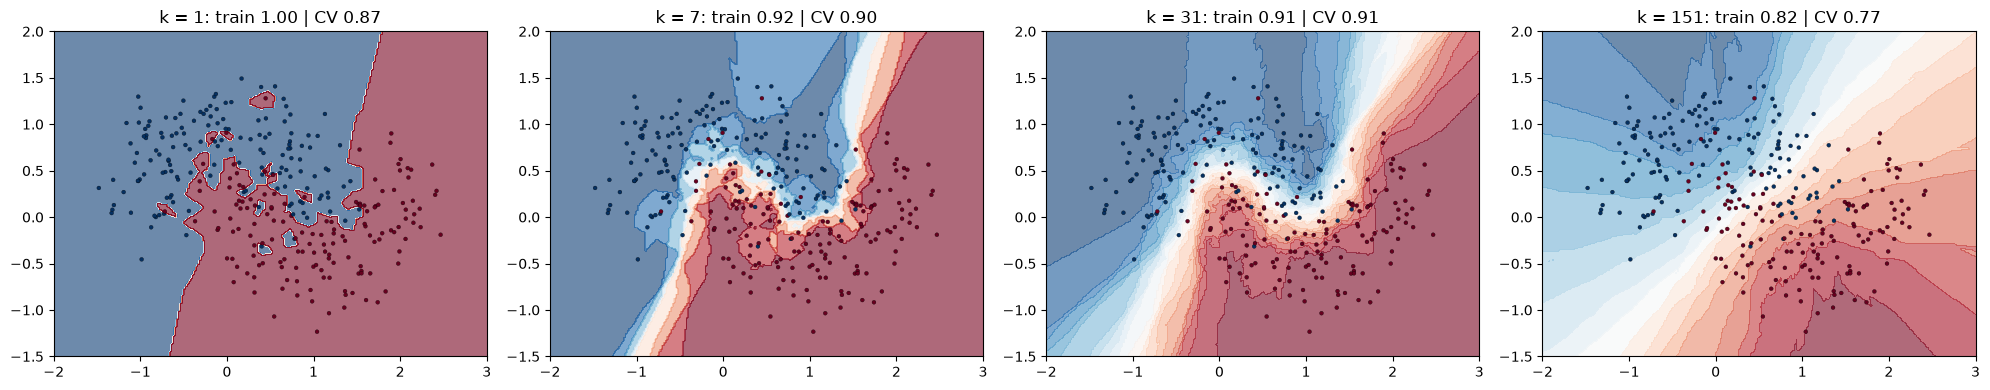

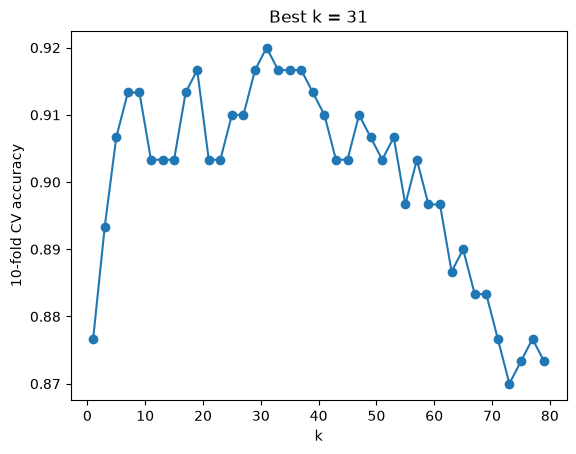

In [3]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(300, noise=0.3, random_state=1)
xx, yy = np.meshgrid(np.linspace(-2, 3, 250), np.linspace(-1.5, 2, 250)); grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, k in zip(axes, [1, 7, 31, 151]):
    m = KNeighborsClassifier(k).fit(Xm, ym)
    ax.contourf(xx, yy, m.predict_proba(grid)[:, 1].reshape(xx.shape), levels=20, cmap="RdBu_r", alpha=0.6)
    ax.scatter(*Xm.T, c=ym, cmap="RdBu_r", s=8, edgecolor="k", lw=0.2)
    ax.set_title(f"k = {k}: train {m.score(Xm, ym):.2f} | CV {cross_val_score(KNeighborsClassifier(k), Xm, ym, cv=5).mean():.2f}")
plt.tight_layout(); plt.show()

ks = np.arange(1, 80, 2)
cv_scores = [cross_val_score(KNeighborsClassifier(k), Xm, ym, cv=10).mean() for k in ks]
plt.plot(ks, cv_scores, "o-"); plt.xlabel("k"); plt.ylabel("10-fold CV accuracy"); plt.title(f"Best k = {ks[np.argmax(cv_scores)]}"); plt.show()

## **3. Distance Metrics**

| Metric | Formula | Use |
|---|---|---|
| Euclidean (L2) | $\sqrt{\sum (x_i-z_i)^2}$ | Default, continuous scaled features |
| Manhattan (L1) | $\sum\lvert x_i-z_i\rvert$ | Robust to single large differences; grid-like spaces |
| Minkowski (Lp) | $(\sum\lvert x_i-z_i\rvert^p)^{1/p}$ | Generalises L1 (p=1) and L2 (p=2) |
| Cosine | $1-\frac{\mathbf x\cdot\mathbf z}{\lVert\mathbf x\rVert\lVert\mathbf z\rVert}$ | Direction matters, not magnitude: text, spectra (illumination) |
| Mahalanobis | $\sqrt{(\mathbf x-\mathbf z)^\top S^{-1}(\mathbf x-\mathbf z)}$ | Accounts for feature correlations and scale |
| Hamming | fraction of differing positions | Binary / categorical vectors |
| Haversine | great-circle distance | Latitude / longitude |

In [4]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(make_pipeline(StandardScaler(), KNeighborsClassifier()),
                           [{"kneighborsclassifier__metric": ["euclidean", "manhattan", "cosine", "chebyshev"],
                             "kneighborsclassifier__n_neighbors": [3, 5, 9, 15],
                             "kneighborsclassifier__weights": ["uniform", "distance"]}], cv=5).fit(X, y)
res = pd.DataFrame(grid_search.cv_results_)
print(res.groupby("param_kneighborsclassifier__metric").mean_test_score.max().round(4).sort_values(ascending=False))
print("Best:", grid_search.best_params_)

param_kneighborsclassifier__metric
manhattan    0.9665
euclidean    0.9663
cosine       0.9608
chebyshev    0.9325
Name: mean_test_score, dtype: float64
Best: {'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 9, 'kneighborsclassifier__weights': 'uniform'}


### Cosine distance and illumination
Two pixels of the same surface under different illumination have spectra that differ by a **scale factor**. A realistic trap: training samples were collected in **sunlit** areas, but the map also contains **shadowed** slopes. Euclidean kNN matches shadowed pixels to whatever class is darkest; cosine distance (the spectral angle) compares only the **shape** of the spectrum.

In [5]:
spectra = {"vegetation": np.array([0.04, 0.07, 0.05, 0.45, 0.30]), "soil": np.array([0.10, 0.14, 0.18, 0.25, 0.30]),
           "water": np.array([0.06, 0.05, 0.03, 0.02, 0.01])}
def simulate(illum_lo, illum_hi, n=200):
    Xs_, ys_ = [], []
    for c, s in enumerate(spectra.values()):
        illum = rng.uniform(illum_lo, illum_hi, n)[:, None]
        Xs_.append(illum * s + rng.normal(0, 0.005, (n, 5))); ys_ += [c] * n
    return np.vstack(Xs_), np.array(ys_)
X_sun, y_sun = simulate(0.9, 1.5)            # training: sunlit
X_shade, y_shade = simulate(0.15, 0.6)       # mapping: shadowed slopes
for metric in ["euclidean", "cosine"]:
    acc = KNeighborsClassifier(5, metric=metric).fit(X_sun, y_sun).score(X_shade, y_shade)
    print(f"{metric:<10} accuracy on shadowed pixels: {acc:.3f}")

euclidean  accuracy on shadowed pixels: 0.453
cosine     accuracy on shadowed pixels: 0.995


## **4. Scaling Is Essential**

In [6]:
print("kNN without scaling:", cross_val_score(KNeighborsClassifier(5), X, y, cv=5).mean().round(3))
print("kNN with scaling   :", cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(5)), X, y, cv=5).mean().round(3))

kNN without scaling: 0.691
kNN with scaling   : 0.949


## **5. kNN Regression and Weighted kNN**

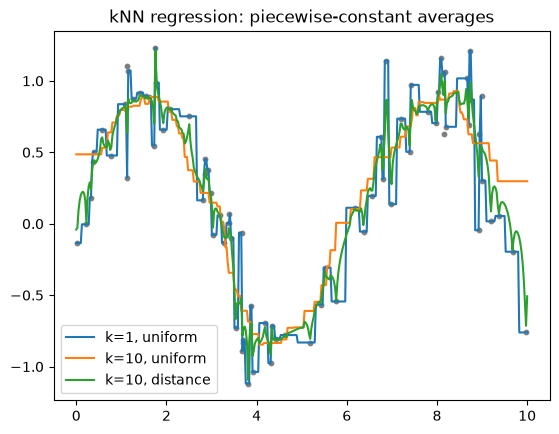

In [7]:
xr = np.sort(rng.uniform(0, 10, 80)); yr = np.sin(xr) + rng.normal(0, 0.25, 80)
g = np.linspace(0, 10, 400)[:, None]
plt.scatter(xr, yr, s=10, c="grey")
for k, w in [(1, "uniform"), (10, "uniform"), (10, "distance")]:
    plt.plot(g, KNeighborsRegressor(k, weights=w).fit(xr[:, None], yr).predict(g), label=f"k={k}, {w}")
plt.legend(); plt.title("kNN regression: piecewise-constant averages"); plt.show()

## **6. Fast Neighbour Search**
Brute force costs $O(n)$ per query. **KD-trees** (low dimensions) and **Ball-trees** (more dimensions, any metric) partition space so most points are never examined. For millions of points in high dimensions, approximate methods (FAISS, HNSW) are used, e.g. for vector databases in LLM retrieval (Day 76).

In [8]:
import time
big = rng.normal(size=(100_000, 3)); q = rng.normal(size=(2000, 3))
for algo in ["brute", "kd_tree", "ball_tree"]:
    m = KNeighborsClassifier(5, algorithm=algo).fit(big, rng.integers(0, 2, 100_000))
    t = time.perf_counter(); m.kneighbors(q); print(f"{algo:<10} {time.perf_counter() - t:.3f}s for 2000 queries")

brute      0.093s for 2000 queries
kd_tree    0.008s for 2000 queries
ball_tree  0.077s for 2000 queries


# **Part 2: Going Deeper - The Curse of Dimensionality**

In high dimensions, **all points are far apart and almost equally far**. The ratio between the nearest and farthest distance approaches 1, so "nearest" loses meaning. Also, to capture a fraction $r$ of uniformly distributed data, a neighbourhood cube needs edge length $r^{1/d}$: in 100-D, capturing 1% of the data needs a cube spanning 95% of every axis.

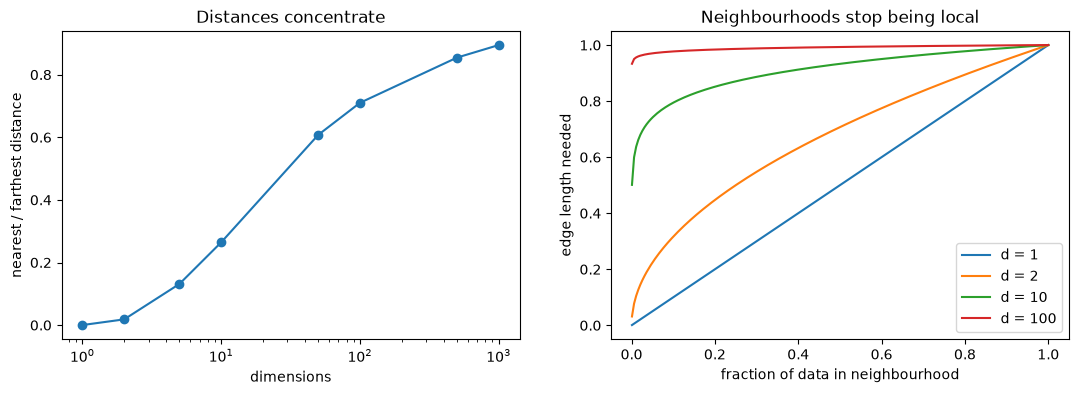

In [9]:
dims = [1, 2, 5, 10, 50, 100, 500, 1000]
ratios = []
for d in dims:
    P = rng.uniform(size=(1000, d)); q0 = rng.uniform(size=d)
    dist = np.linalg.norm(P - q0, axis=1)
    ratios.append(dist.min() / dist.max())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(dims, ratios, "o-"); axes[0].set(xlabel="dimensions", ylabel="nearest / farthest distance", title="Distances concentrate")
r_ = np.linspace(0.001, 1, 200)
for d in [1, 2, 10, 100]:
    axes[1].plot(r_, r_ ** (1 / d), label=f"d = {d}")
axes[1].set(xlabel="fraction of data in neighbourhood", ylabel="edge length needed", title="Neighbourhoods stop being local"); axes[1].legend()
plt.show()

In [10]:
# kNN accuracy as irrelevant dimensions are added
base_X, base_y = make_moons(600, noise=0.2, random_state=0)
for extra in [0, 2, 10, 50, 200]:
    Xd = np.c_[base_X, rng.normal(size=(600, extra))]
    print(f"{extra:>3} noise dimensions: kNN CV accuracy {cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(15)), Xd, base_y, cv=5).mean():.3f}")

  0 noise dimensions: kNN CV accuracy 0.968
  2 noise dimensions: kNN CV accuracy 0.933
 10 noise dimensions: kNN CV accuracy 0.860
 50 noise dimensions: kNN CV accuracy 0.758
200 noise dimensions: kNN CV accuracy 0.640


Real data usually lies near a **low-dimensional manifold**, which is why kNN can still work on images. Feature selection (Day 43) and dimensionality reduction (Day 49-50) restore locality.

## **Practice Problems**
1. Implement **Mahalanobis** kNN: whiten the data with the inverse Cholesky factor of the covariance, then use Euclidean kNN. Compare on the wine data.
2. Add `weights="distance"` to our scratch class.
3. Use `KNeighborsClassifier` with `metric="haversine"` (inputs in radians) to classify points by nearest city.
4. *(Advanced)* Plot CV accuracy vs k for k = 1..100 on the 10-noise-dimension moons. Does the best k change compared with 0 noise dimensions?

In [11]:
# Solution 1
L = np.linalg.cholesky(np.cov(Xtr.T)); W = np.linalg.inv(L)
Xw_tr, Xw_te = (Xtr - Xtr.mean(0)) @ W.T, (Xte - Xtr.mean(0)) @ W.T
print("Mahalanobis kNN accuracy:", round(KNeighborsClassifier(5).fit(Xw_tr, ytr).score(Xw_te, yte), 3))
# Solution 2
class WeightedKNN(KNNScratch):
    def predict(self, X):
        d = np.sqrt(((np.asarray(X)[:, None, :] - self.X_[None]) ** 2).sum(-1)); nn = np.argsort(d, 1)[:, :self.k]
        w = 1 / (np.take_along_axis(d, nn, 1) + 1e-12)
        return np.array([np.bincount(self.y_[nn[i]], weights=w[i]).argmax() for i in range(len(nn))])
print("Weighted scratch accuracy:", np.mean(WeightedKNN(5).fit(sc.transform(Xtr), ytr).predict(sc.transform(Xte)) == yte).round(3))
# Solution 3
cities = np.radians([[22.57, 88.36], [23.80, 86.43], [23.34, 85.31]])                     # Kolkata, Dhanbad, Ranchi
names = np.array(["Kolkata", "Dhanbad", "Ranchi"])
pts = np.radians([[22.8, 88.0], [23.6, 86.0], [23.2, 85.6]])
print(names[KNeighborsClassifier(1, metric="haversine").fit(cities, [0, 1, 2]).predict(pts)])
# Solution 4
Xd10 = np.c_[base_X, rng.normal(size=(600, 10))]
for name, Xc in [("0 noise dims", base_X), ("10 noise dims", Xd10)]:
    s = [cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(k)), Xc, base_y, cv=5).mean() for k in range(1, 101, 3)]
    print(f"{name}: best k = {list(range(1, 101, 3))[int(np.argmax(s))]}, accuracy {max(s):.3f}")

Mahalanobis kNN accuracy: 0.944
Weighted scratch accuracy: 0.963
['Kolkata' 'Dhanbad' 'Ranchi']


0 noise dims: best k = 4, accuracy 0.970


10 noise dims: best k = 19, accuracy 0.872


## **Key References**
- Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory*, 13(1), 21-27.
- Beyer, K., Goldstein, J., Ramakrishnan, R., & Shaft, U. (1999). When is "nearest neighbor" meaningful? *ICDT 1999*, 217-235.
- Bentley, J. L. (1975). Multidimensional binary search trees used for associative searching. *Communications of the ACM*, 18(9), 509-517.
- Kruse, F. A. et al. (1993). The spectral image processing system (SIPS): interactive visualization and analysis of imaging spectrometer data. *Remote Sensing of Environment*, 44(2-3), 145-163 (Spectral Angle Mapper).